# Контроль температуры сплава для металлургического комбината «Стальная птица»

Металлургический комбинат «Стальная птица» оптимизирует производственные расходы, для чего уменьшает потребление электроэнергии на этапе обработки стали. Необходим контроль температуры сплава, во-первых, для сохранения температуры в некотором диапазоне, чтобы не перегревать сплав и не использовать лишнюю энергию, а также для увеличения срока службы ковша.

**Цель исследования:** построить модель для предсказания температуры сплава. 

Разработанная модель будет имитировать технологический процесс, поэтому важно знать **шаги по обработке стали**:
- Берется металлический ковш вместимостью около 100 тонн, облицованный изнутри огнеупорным кирпичом для выдерживания высоких температур
- Расплавленная сталь заливается в ковш
- Расплавленная сталь подогревается до нужной температуры графитовыми электродами, установленными в крышке ковша
- Измеряется температура стали и производится химический анализ 
- Проводится корректировка химического состава (легировать = изменять состав): десульфурация (вывод серы), добавление примесей - куски сплава подаются из бункера сыпучих материалов или проволока через трайб-аппарат (от англ. tribe — «масса»); отбираются пробы
    - повышают температуру сплава на несколько минут
    - добавляют легирующие материалы и продувают сплав инертным газом
    - сплав перемешивают
    - проводят измерения
    - повторяют цикл до достижения целевого химического состава и оптимальной температуры плавки.
- Расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки, откуда готовый продукт выходит в виде заготовок-слябов (от англ. slab — «плита»).

Поэтому **объект моделирования** в данном исследовании - ковш, не строка. Будем моделировать поведение ковша. Важные факторы:
- температура на входе, начальное состояние объекта. **Целевая переменная** - температура розлива стали, после того, как сплав соответствует всем параметрам. По ходу исследования необходимо будет подтвердить информацию о температуре плавления стали не менее 1400 градусов для выделения объектов, которые не подходят для моделирования. Определим как можно учесть затрачиваемую энергию (полная мощность, относительная мощность, работа)


**Ход исследования:**
1. Загрузка данных
2. Обзор данных
3. Предобработка данных
4. Объединение данных
5. EDA и корреляционный анализ
6. Обучение моделей и выбор лучшей
7. Анализ важности факторов - для понимания, какие именно процессы больше влияют на перегрев 
8. Итоговый вывод

**Описание данных**
Информация по сплавам получена из различных датасетов:
- `data_arc_new.csv` — данные об электродах;
    - `key` — номер партии;
    - `Начало нагрева дугой` — время начала нагрева;
    - `Конец нагрева дугой` — время окончания нагрева;
    - `Активная мощность` — значение активной мощности;
    - `Реактивная мощность` — значение реактивной мощности.
- `data_bulk_new.csv` — данные о подаче сыпучих материалов (объём);
    - `key` — номер партии;
    - `Bulk 1` … `Bulk 15` — объём подаваемого материала.
- `data_bulk_time_new.csv` — данные о подаче сыпучих материалов (время);
    - `key` — номер партии;
    - `Bulk 1` … `Bulk 15` —  время подачи материала.
- `data_gas_new.csv` — данные о продувке сплава газом;
    - `key` — номер партии;
    - `Газ 1` — объём подаваемого газа.
- `data_temp_new.csv` — результаты измерения температуры;
  - `key` — номер партии;
  - `Время замера` — время замера;
  - `Температура` — значение температуры.
- `data_wire_new.csv` — данные о проволочных материалах (объём);
    - `key` — номер партии;
    - `Wire 1` … `Wire 9` — объём подаваемых проволочных материалов.
- `data_wire_time_new.csv` — данные о проволочных материалах (время).
    - `key` — номер партии;
    - `Wire 1` … `Wire 9` — время подачи проволочных материалов.

В файлах может быть несколько строк с одинаковым значением key: они соответствуют разным итерациям обработки.

In [1]:
! pip install catboost --quiet
! pip install optuna --quiet
! pip install phik --quiet
! pip install shap --quiet

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from catboost import CatBoostRegressor

import phik

import optuna
from optuna.samplers import RandomSampler

import shap

In [3]:
RANDOM_STATE = 61125

## Загрузка, предобработка и исследование данных

In [4]:
try:
    arc = pd.read_csv('data_arc_new.csv', parse_dates=[1, 2])
    bu = pd.read_csv('data_bulk_new.csv')
    bu_ti = pd.read_csv('data_bulk_time_new.csv', parse_dates=list(range(1, 16)))
    gas = pd.read_csv('data_gas_new.csv')
    temp = pd.read_csv('data_temp_new.csv', parse_dates=[1])
    wi = pd.read_csv('data_wire_new.csv')
    wi_ti = df_wire_time = pd.read_csv('data_wire_time_new.csv', parse_dates=list(range(1, 10)))
except:
    arc = pd.read_csv('https://code.s3.yandex.net/datasets/data_arc_new.csv', parse_dates=[1, 2])
    bu = pd.read_csv('https://code.s3.yandex.net/datasets/data_bulk_new.csv')
    bu_ti = pd.read_csv('https://code.s3.yandex.net/datasets/data_bulk_time_new.csv', parse_dates=list(range(1, 16)))
    gas = pd.read_csv('https://code.s3.yandex.net/datasets/data_gas_new.csv')
    temp = pd.read_csv('https://code.s3.yandex.net/datasets/data_temp_new.csv', parse_dates=[1])
    wi = pd.read_csv('https://code.s3.yandex.net/datasets/data_wire_new.csv')
    wi_ti = df_wire_time = pd.read_csv('https://code.s3.yandex.net/datasets/data_wire_time_new.csv', parse_dates=list(range(1, 10)))

In [5]:
sns.set_style('darkgrid')

### Данные об электродах

In [6]:
arc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   key                   14876 non-null  int64         
 1   Начало нагрева дугой  14876 non-null  datetime64[ns]
 2   Конец нагрева дугой   14876 non-null  datetime64[ns]
 3   Активная мощность     14876 non-null  float64       
 4   Реактивная мощность   14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 581.2 KB


In [7]:
arc.head()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


In [8]:
a = arc['key'].value_counts()
a

2108    16
1689    15
1513    15
2567    14
46      13
        ..
977      1
247      1
2582     1
248      1
530      1
Name: key, Length: 3214, dtype: int64

In [9]:
frec = a.groupby(a.values).size()
frec

1      39
2     174
3     520
4     892
5     759
6     490
7     205
8      84
9      28
10      9
11      5
12      3
13      2
14      1
15      2
16      1
Name: key, dtype: int64

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


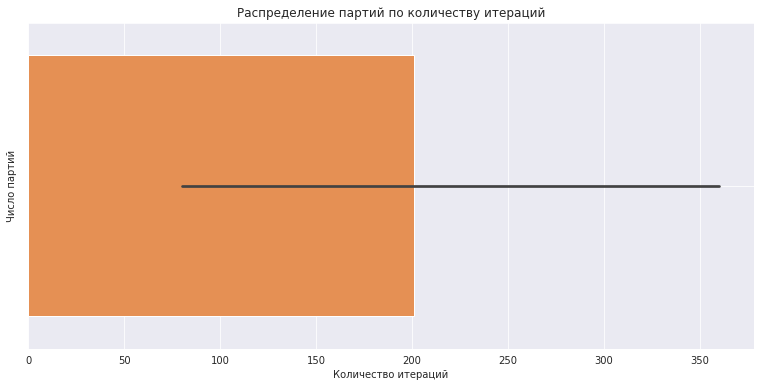

In [10]:
plt.figure(figsize=(13, 6))
sns.barplot(frec, palette='YlOrRd')
plt.xlabel('Количество итераций')
plt.ylabel('Число партий')
plt.title('Распределение партий по количеству итераций')
plt.grid(True)
plt.show()

In [11]:
sum(arc.duplicated())

0

In [12]:
arc.describe()

,key,Активная мощность,Реактивная мощность
count,14876.000000,14876.000000,14876.000000
mean,1615.220422,0.662752,0.438986
std,934.571502,0.258885,5.873485
min,1.000000,0.223120,-715.479924
25%,806.000000,0.467115,0.337175
50%,1617.000000,0.599587,0.441639
75%,2429.000000,0.830070,0.608201
max,3241.000000,1.463773,1.270284


In [13]:
arc['key'].nunique()

3214

In [14]:
arc['duration'] = arc['Конец нагрева дугой'] - arc['Начало нагрева дугой']
arc.head()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность,duration
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,0 days 00:03:48
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,0 days 00:03:05
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,0 days 00:02:52
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,0 days 00:06:05
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,0 days 00:02:28


In [15]:
arc['duration'].describe()

count                        14876
mean     0 days 00:02:51.670946490
std      0 days 00:01:38.186802680
min                0 days 00:00:11
25%                0 days 00:01:47
50%                0 days 00:02:27
75%                0 days 00:03:34
max                0 days 00:15:07
Name: duration, dtype: object

In [16]:
arc['minutes'] = arc['duration'].dt.total_seconds() / 60
arc['minutes'] 

0        3.800000
1        3.083333
2        2.866667
3        6.083333
4        2.466667
           ...   
14871    2.616667
14872    3.000000
14873    3.066667
14874    0.950000
14875    1.350000
Name: minutes, Length: 14876, dtype: float64

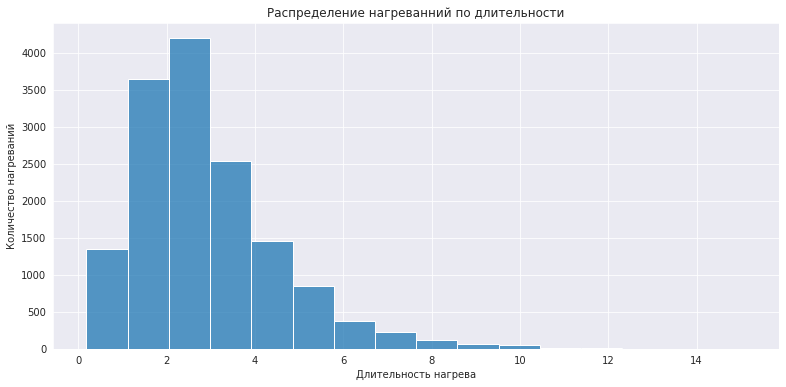

In [17]:
plt.figure(figsize=(13, 6))
sns.histplot(data=arc, x='minutes', bins=16)
plt.xlabel('Длительность нагрева')
plt.ylabel('Количество нагреваний')
plt.title('Распределение нагреваний по длительности')
plt.grid(True)
plt.show()

In [18]:
arc['power'] = (arc['Активная мощность']**2 + arc['Реактивная мощность']**2)**0.5
arc['coef'] = arc['Активная мощность'] / arc['power']
arc.head()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность,duration,minutes,power,coef
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,0 days 00:03:48,3.800000,0.371123,0.822181
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,0 days 00:03:05,3.083333,0.902319,0.848545
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,0 days 00:02:52,2.866667,0.722536,0.803161
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,0 days 00:06:05,6.083333,0.642824,0.806591
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,0 days 00:02:28,2.466667,1.079934,0.802950


In [19]:
arc.coef.describe()

count    14876.000000
mean         0.805833
std          0.028432
min          0.000986
25%          0.788046
50%          0.809703
75%          0.827038
max          0.880503
Name: coef, dtype: float64

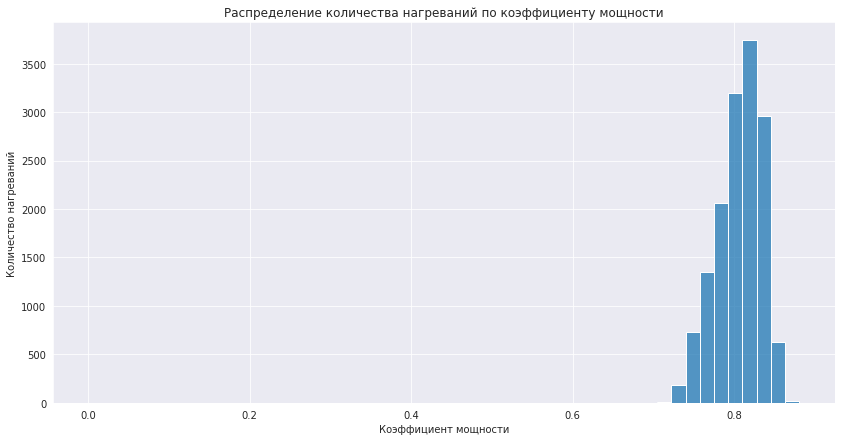

In [20]:
plt.figure(figsize=(14, 7))
sns.histplot(data=arc, x='coef', bins=50)
plt.xlabel('Коэффициент мощности')
plt.ylabel('Количество нагреваний')
plt.title('Распределение количества нагреваний по коэффициенту мощности')
plt.grid(True)
plt.show()

In [21]:
arc[arc['coef'] < 0.6]

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность,duration,minutes,power,coef
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924,0 days 00:01:49,1.816667,715.480272,0.000986


In [22]:
arc[arc['Реактивная мощность'] < 0]

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность,duration,minutes,power,coef
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924,0 days 00:01:49,1.816667,715.480272,0.000986


In [23]:
mask = arc[arc['key'] == 2116]
ind = mask.index.tolist()
mask

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность,duration,minutes,power,coef
9778,2116,2019-07-28 02:07:12,2019-07-28 02:09:14,0.787549,0.693881,0 days 00:02:02,2.033333,1.049621,0.750317
9779,2116,2019-07-28 02:13:10,2019-07-28 02:15:25,0.580263,0.411498,0 days 00:02:15,2.250000,0.711362,0.815707
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924,0 days 00:01:49,1.816667,715.480272,0.000986
9781,2116,2019-07-28 02:29:11,2019-07-28 02:30:18,0.563641,0.408513,0 days 00:01:07,1.116667,0.696114,0.809697


In [24]:
arc = arc.drop(ind)

In [25]:
arc.coef.describe()

count    14872.000000
mean         0.805890
std          0.027655
min          0.707722
25%          0.788058
50%          0.809705
75%          0.827039
max          0.880503
Name: coef, dtype: float64

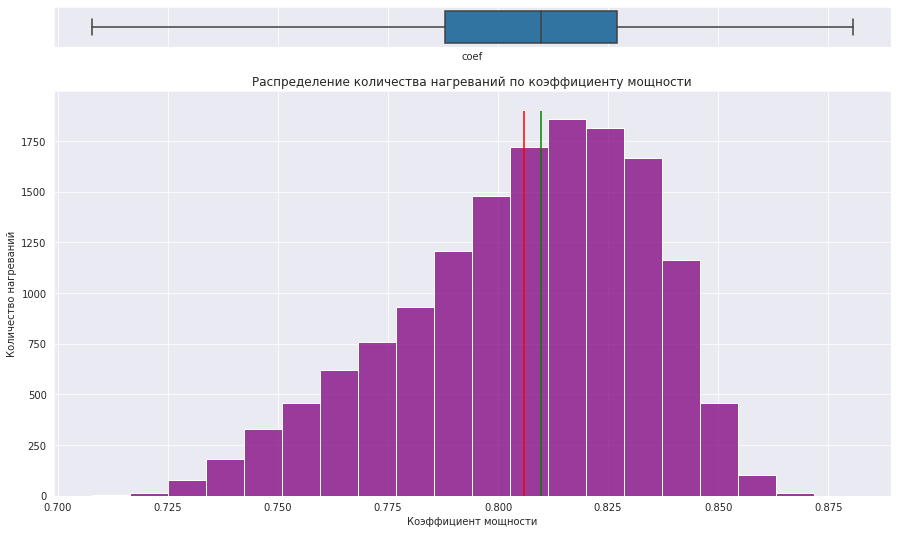

In [26]:
_, [axs_b, axs_hi] = plt.subplots(2, 1, figsize=(15, 9), sharex=True, gridspec_kw=dict(height_ratios=[1, 10])) 
sns.boxplot(data=arc, x='coef', whis=3, orient='h', ax=axs_b)
sns.histplot(data=arc, x='coef', bins=20, color='purple', ax=axs_hi)
plt.vlines(arc['coef'].mean(), ymin=0, ymax=1900, colors='red', label='среднее')
plt.vlines(arc['coef'].median(), ymin=0, ymax=1900, colors='green', label='медиана')
plt.xlabel('Коэффициент мощности')
plt.ylabel('Количество нагреваний')
plt.title('Распределение количества нагреваний по коэффициенту мощности')
plt.grid(True)
plt.show()

In [27]:
arc['work'] = arc['Активная мощность'] * arc['minutes']

In [28]:
arc['work'].describe()

count    14872.000000
mean         1.900925
std          1.383561
min          0.087442
25%          0.956282
50%          1.536709
75%          2.433129
max         14.970015
Name: work, dtype: float64

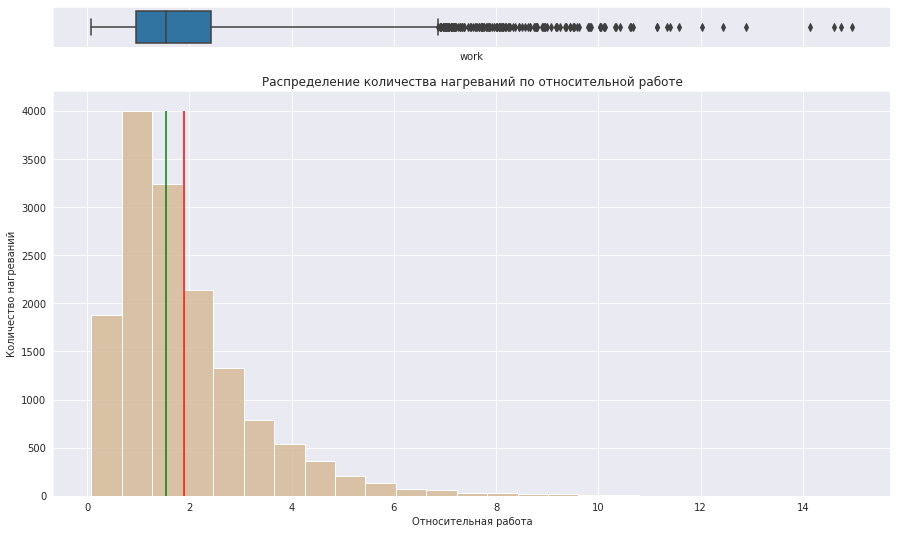

In [29]:
_, [axs_b, axs_hi] = plt.subplots(2, 1, figsize=(15, 9), sharex=True, gridspec_kw=dict(height_ratios=[1, 10])) 
sns.boxplot(data=arc, x='work', whis=3, orient='h', ax=axs_b)
sns.histplot(data=arc, x='work', bins=25, color='tan')
plt.vlines(arc['work'].mean(), ymin=0, ymax=4000, colors='red', label='среднее')
plt.vlines(arc['work'].median(), ymin=0, ymax=4000, colors='green', label='медиана')
plt.xlabel('Относительная работа')
plt.ylabel('Количество нагреваний')
plt.title('Распределение количества нагреваний по относительной работе')
plt.grid(True)
plt.show()

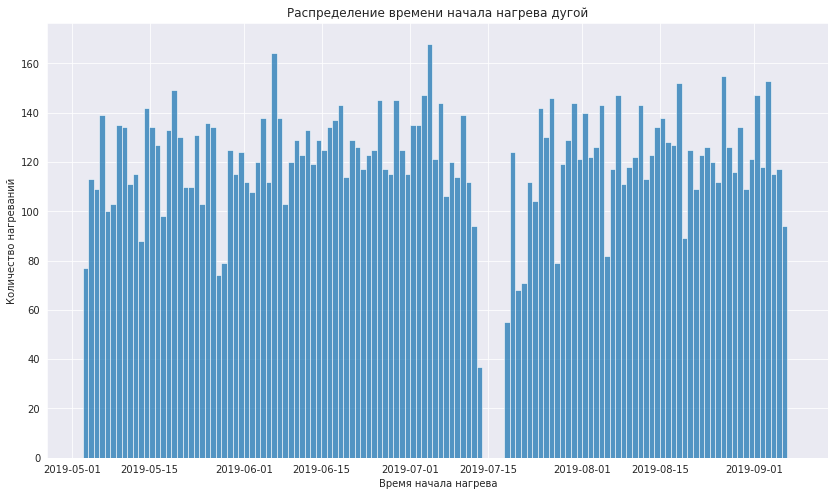

In [30]:
plt.figure(figsize=(14, 8))
sns.histplot(data=arc, x='Начало нагрева дугой', discrete=True)
plt.title('Распределение времени начала нагрева дугой')
plt.xlabel('Время начала нагрева')
plt.ylabel('Количество нагреваний');

In [31]:
arc['Начало нагрева дугой'].dt.day[arc['Начало нагрева дугой'].dt.month == 7].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 18, 19, 20, 21,
       22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

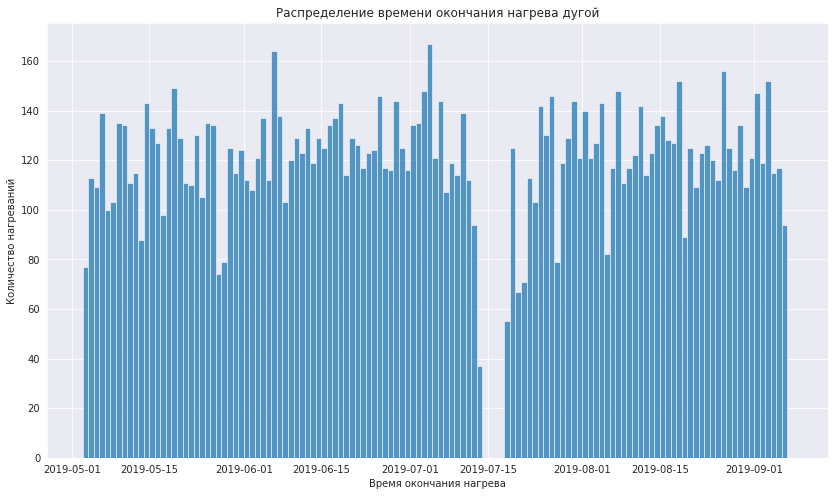

In [32]:
plt.figure(figsize=(14, 8))
sns.histplot(data=arc, x='Конец нагрева дугой', discrete=True)
plt.title('Распределение времени окончания нагрева дугой')
plt.xlabel('Время окончания нагрева')
plt.ylabel('Количество нагреваний');

In [33]:
arc['Конец нагрева дугой'].dt.day[arc['Конец нагрева дугой'].dt.month == 7].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 18, 19, 20, 21,
       22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

**Вывод**:
- нет пропусков, нет дубликатов
- в датасете 3213 партий, хотя максимальное значение столбца `key` 3241 - значит информация о каких-либо партиях отсутствует
- максимальное число итераций для одной партии - 16 штук, минимальное число - 1 штука, в основном количество итераций не превышает 10, чаще всего сплав обрабатывается 4-5 раз
- В основном нагревание длится до 5 минут, чаще всего около 3 минут
- Удалены значения партии (2116) с аномальной реактивной мощностью, вероятнее всего, большой отрицательный показатель указывает на сбой, так как остальные значения в относительных единицах (от 0 до 1).
- Данные представлены за период с мая по сентябрь 2019 года, в данных по времени начала и окончания нагревания отсутствуют записи в июле в течение одного и того же периода - с 14 по 17 число. Также неполные данные по соседним с этим периодом дням - 13 и 18 июля, возможно, был сбой в работе и только 18.07 работа возобновилась 
- Добавлены новые признаки:
    - продолжительность нагрева в минутах,
    - коэффициент мощности, в котором значение 1 означает эффективное использование энергии, а низкий коэффициент мощности (ближе к 0) указывает на потери, вызванные, например, реактивной мощностью.
    - работа в относительных единицах указывает на энергию, подведённую к сплаву, более высокие значения работы указывают на большее воздействие энергии для увеличения температуры, в данном признаке присутствуют выбросы
- В дальнейшем исследуем зависимость температуры от последних двух добавленных признаков

### Сыпучие материалы

In [34]:
bu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.2 KB


In [35]:
bu_ti.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   key      3129 non-null   int64         
 1   Bulk 1   252 non-null    datetime64[ns]
 2   Bulk 2   22 non-null     datetime64[ns]
 3   Bulk 3   1298 non-null   datetime64[ns]
 4   Bulk 4   1014 non-null   datetime64[ns]
 5   Bulk 5   77 non-null     datetime64[ns]
 6   Bulk 6   576 non-null    datetime64[ns]
 7   Bulk 7   25 non-null     datetime64[ns]
 8   Bulk 8   1 non-null      datetime64[ns]
 9   Bulk 9   19 non-null     datetime64[ns]
 10  Bulk 10  176 non-null    datetime64[ns]
 11  Bulk 11  177 non-null    datetime64[ns]
 12  Bulk 12  2450 non-null   datetime64[ns]
 13  Bulk 13  18 non-null     datetime64[ns]
 14  Bulk 14  2806 non-null   datetime64[ns]
 15  Bulk 15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](15), int64(1)
memory usage: 391.2 KB


In [36]:
(bu_ti.isna() == bu.isna()).sum().to_frame()

,0
key,3129
Bulk 1,3129
Bulk 2,3129
Bulk 3,3129
Bulk 4,3129
Bulk 5,3129
Bulk 6,3129
Bulk 7,3129
Bulk 8,3129
Bulk 9,3129


In [37]:
bu['key'].nunique()

3129

In [38]:
bu.key.value_counts()

2049    1
2612    1
2588    1
541     1
2590    1
       ..
1090    1
3139    1
1092    1
3141    1
2047    1
Name: key, Length: 3129, dtype: int64

In [39]:
sum(bu.duplicated())

0

In [40]:
for column in bu.columns:
    if 'B' in column:
        print(column)
        print(bu[column].describe())

Bulk 1
count    252.000000
mean      39.242063
std       18.277654
min       10.000000
25%       27.000000
50%       31.000000
75%       46.000000
max      185.000000
Name: Bulk 1, dtype: float64
Bulk 2
count     22.000000
mean     253.045455
std       21.180578
min      228.000000
25%      242.000000
50%      251.500000
75%      257.750000
max      325.000000
Name: Bulk 2, dtype: float64
Bulk 3
count    1298.000000
mean      113.879045
std        75.483494
min         6.000000
25%        58.000000
50%        97.500000
75%       152.000000
max       454.000000
Name: Bulk 3, dtype: float64
Bulk 4
count    1014.000000
mean      104.394477
std        48.184126
min        12.000000
25%        72.000000
50%       102.000000
75%       133.000000
max       281.000000
Name: Bulk 4, dtype: float64
Bulk 5
count     77.000000
mean     107.025974
std       81.790646
min       11.000000
25%       70.000000
50%       86.000000
75%      132.000000
max      603.000000
Name: Bulk 5, dtype: float64
Bulk

In [41]:
bu_ti.describe().T

,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.0,1622.0,2431.0,3241.0


Поскольку данные за тот же период с мая по сентябрь 2019 года, предположим, что данные за период 14-17 также будут отсутствовать, проверим на гистограмме материал с наибольшим числом добавлений Bulk 14

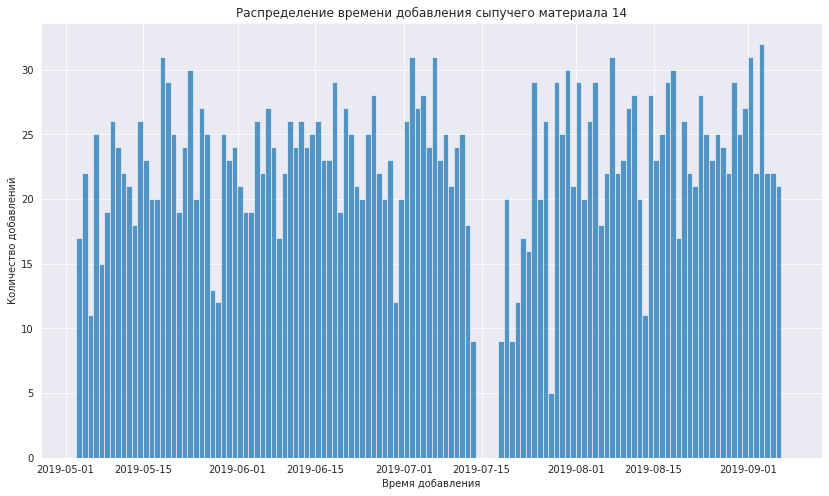

In [42]:
plt.figure(figsize=(14, 8))
sns.histplot(data=bu_ti, x='Bulk 14', discrete=True)
plt.title('Распределение времени добавления сыпучего материала 14')
plt.xlabel('Время добавления')
plt.ylabel('Количество добавлений');

In [43]:
bu = bu.fillna(0)
bu.isna().sum()

key        0
Bulk 1     0
Bulk 2     0
Bulk 3     0
Bulk 4     0
Bulk 5     0
Bulk 6     0
Bulk 7     0
Bulk 8     0
Bulk 9     0
Bulk 10    0
Bulk 11    0
Bulk 12    0
Bulk 13    0
Bulk 14    0
Bulk 15    0
dtype: int64

**Вывод**
- пропуски в 2 датасетах совпадают, они указывают на то, что сыпучие материалы не использовались при легировании
- мы заполнили пропуски нулями, так как они были заранее объяснены заказчиком и обозначают недобавление материалов
- пропуски в датасете с временем не были заполнены, так как эти данные не будут использованы в модели
- сыпучие материалы добавлялись в 3129 партий из 3241
- номер партии в датасетах не повторяется, это значит, что в партию определенные виды сыпучих материалов добавляли только 1 раз
- наиболее часто добавляемыми материалами были номера 3, 4, 12, 14, 15
- в наибольших объёмах добавляли материалы под номерами 2, 7, 12, 13, 14, 15
- в данных по времени также заметен пропуск в тот же период с 14 по 17 июля, что может подтвердить гипотезу о сбое на производстве

### Проволочные материалы

In [44]:
wi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


In [45]:
wi_ti.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   key     3081 non-null   int64         
 1   Wire 1  3055 non-null   datetime64[ns]
 2   Wire 2  1079 non-null   datetime64[ns]
 3   Wire 3  63 non-null     datetime64[ns]
 4   Wire 4  14 non-null     datetime64[ns]
 5   Wire 5  1 non-null      datetime64[ns]
 6   Wire 6  73 non-null     datetime64[ns]
 7   Wire 7  11 non-null     datetime64[ns]
 8   Wire 8  19 non-null     datetime64[ns]
 9   Wire 9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9), int64(1)
memory usage: 240.8 KB


In [46]:
(wi_ti.isna() == wi.isna()).sum().to_frame()

,0
key,3081
Wire 1,3081
Wire 2,3081
Wire 3,3081
Wire 4,3081
Wire 5,3081
Wire 6,3081
Wire 7,3081
Wire 8,3081
Wire 9,3081


In [47]:
wi.key.nunique()

3081

In [48]:
wi.key.value_counts()

2049    1
2664    1
2590    1
543     1
2592    1
       ..
1090    1
3139    1
1092    1
3141    1
2047    1
Name: key, Length: 3081, dtype: int64

In [49]:
sum(wi.duplicated())

0

In [50]:
for column in wi.columns:
    if 'W' in column:
        print(column)
        print(wi[column].describe())

Wire 1
count    3055.000000
mean      100.895853
std        42.012518
min         1.918800
25%        72.115684
50%       100.158234
75%       126.060483
max       330.314424
Name: Wire 1, dtype: float64
Wire 2
count    1079.000000
mean       50.577323
std        39.320216
min         0.030160
25%        20.193680
50%        40.142956
75%        70.227558
max       282.780152
Name: Wire 2, dtype: float64
Wire 3
count     63.000000
mean     189.482681
std       99.513444
min        0.144144
25%       95.135044
50%      235.194977
75%      276.252014
max      385.008668
Name: Wire 3, dtype: float64
Wire 4
count     14.000000
mean      57.442841
std       28.824667
min       24.148801
25%       40.807002
50%       45.234282
75%       76.124619
max      113.231044
Name: Wire 4, dtype: float64
Wire 5
count     1.000
mean     15.132
std         NaN
min      15.132
25%      15.132
50%      15.132
75%      15.132
max      15.132
Name: Wire 5, dtype: float64
Wire 6
count     73.000000
mean     

In [51]:
wi_ti.describe().T

,count,mean,std,min,25%,50%,75%,max
key,3081.0,1623.426485,932.996726,1.0,823.0,1619.0,2434.0,3241.0


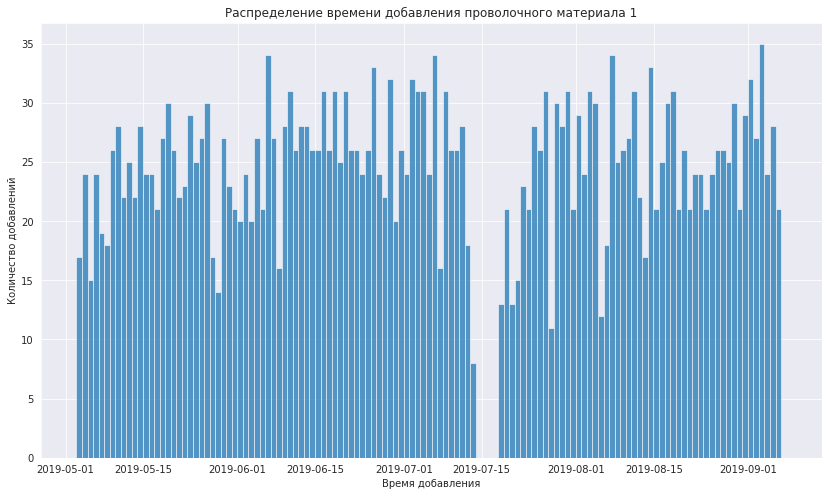

In [52]:
plt.figure(figsize=(14, 8))
sns.histplot(data=wi_ti, x='Wire 1', discrete=True)
plt.title('Распределение времени добавления проволочного материала 1')
plt.xlabel('Время добавления')
plt.ylabel('Количество добавлений');

In [53]:
wi = wi.fillna(0)
wi.isna().sum()

key       0
Wire 1    0
Wire 2    0
Wire 3    0
Wire 4    0
Wire 5    0
Wire 6    0
Wire 7    0
Wire 8    0
Wire 9    0
dtype: int64

**Вывод**
- проволочные материалы добавлялись в 3081 партию из 3241
- пропуски в 2 датасетах совпадают, что значит, что проволочные материалы не были использованы для конкретной партии
- пропуски были заполнены 0, так как они указывают на недобавление определенного материала в конкретную партию
- мы не заполняли пропуски в датасете с временем, так как он не будет использован в дальнейшем 
- номер партии в датасетах не повторяется, это значит, как и в случае с сыпучими материалами, что в партию определенные виды проволочных материалов добавляли только 1 раз
- чаще всего использовали проволочные материалы под номерами 1, 2
- проволочные материалы под номерами 1 и 3 добавляли в больших количествах
- есть пропуск данных за период 14-17 июля

### Продувка газом

In [54]:
gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


In [55]:
gas.head()

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [56]:
gas.describe()

,key,Газ 1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


In [57]:
gas.key.nunique()

3239

In [58]:
gas.key.value_counts()

2049    1
3135    1
3115    1
1070    1
3119    1
       ..
2596    1
549     1
2600    1
553     1
2047    1
Name: key, Length: 3239, dtype: int64

In [59]:
sum(gas.duplicated())

0

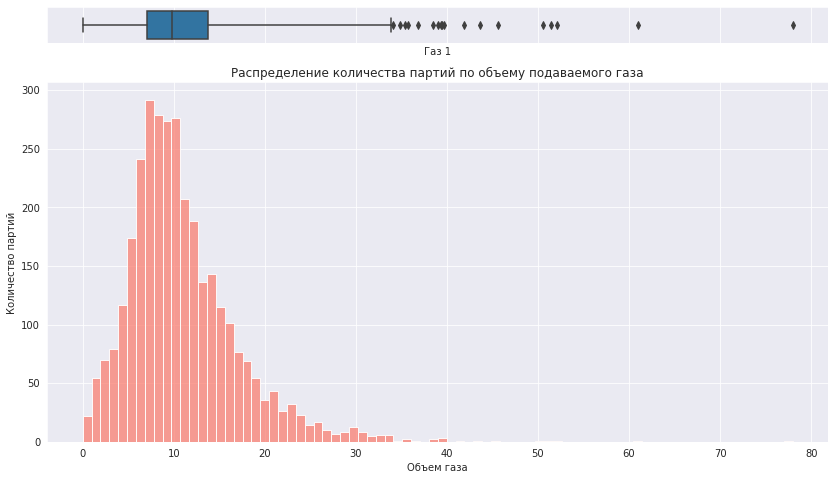

In [60]:
_, [axs_b, axs_hi] = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw=dict(height_ratios=[1, 10])) 
sns.boxplot(data=gas, x='Газ 1', whis=3, orient='h', ax=axs_b)
sns.histplot(data=gas, x='Газ 1', bins=80, color='salmon', ax=axs_hi)
plt.xlabel('Объём газа')
plt.ylabel('Количество партий')
plt.title('Распределение количества партий по объёму подаваемого газа')
plt.grid(True)
plt.show()

**Вывод**
- есть данные по продувке газом для 3239 партий из 3241, то есть отсутствует информация только по двум из них
- каждая партия в датасете встречается один раз, значит указан общий объём подаваемого газа для каждой партии
- нет пропусков, нет дубликатов
- в основном на партию приходится до 20 кубических метров газа, но встречаются и выбросы - значения превышающие 40 кубических метров газа

### Измерение температуры

In [61]:
temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key           18092 non-null  int64         
 1   Время замера  18092 non-null  datetime64[ns]
 2   Температура   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 424.2 KB


In [62]:
temp.key.nunique()

3216

In [63]:
temp.describe()

,key,Температура
count,18092.000000,14665.000000
mean,1616.460977,1590.722741
std,934.641385,20.394381
min,1.000000,1191.000000
25%,807.750000,1580.000000
50%,1618.000000,1590.000000
75%,2429.000000,1599.000000
max,3241.000000,1705.000000


In [64]:
temp.head()

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


In [65]:
temp.duplicated().sum()

0

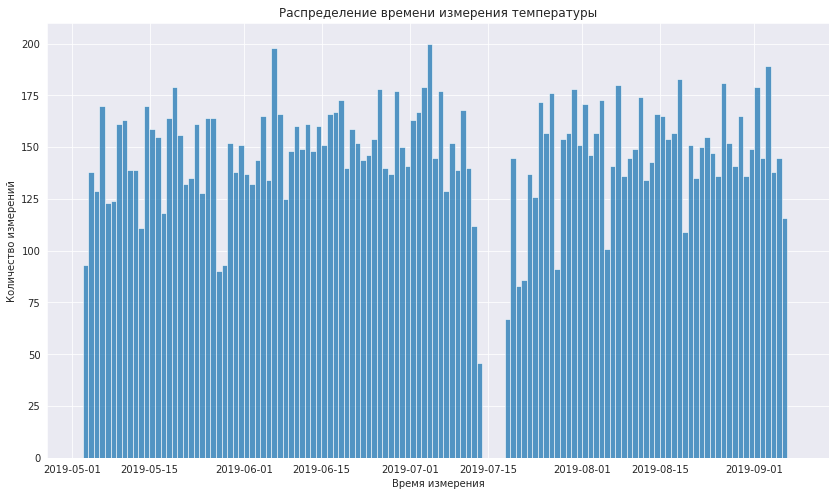

In [66]:
plt.figure(figsize=(14, 8))
sns.histplot(data=temp, x='Время замера', discrete=True)
plt.title('Распределение времени измерения температуры')
plt.xlabel('Время измерения')
plt.ylabel('Количество измерений');

In [67]:
temp.isna().sum()

key                0
Время замера       0
Температура     3427
dtype: int64

In [68]:
b = temp['key'].value_counts()
b

2108    17
1513    16
1689    16
2567    15
322     14
        ..
556      2
1169     2
732      2
195      1
279      1
Name: key, Length: 3216, dtype: int64

In [69]:
te_frec = b.groupby(b.values).size()
te_frec

1       2
2      39
3     174
4     520
5     892
6     759
7     490
8     205
9      84
10     28
11      9
12      5
13      3
14      2
15      1
16      2
17      1
Name: key, dtype: int64

Сравним с распределением по количеству нагреваний электродами

In [70]:
frec

1      39
2     174
3     520
4     892
5     759
6     490
7     205
8      84
9      28
10      9
11      5
12      3
13      2
14      1
15      2
16      1
Name: key, dtype: int64

Таким образом, при измерении температуры данное распределение смещается на единицу, так как температуру измеряют до добавления материалов, а потом нагревают сплав. То есть мы видим две партии, состав которых сразу соответствовал требованиям и их температура измерялась только 1 раз.

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


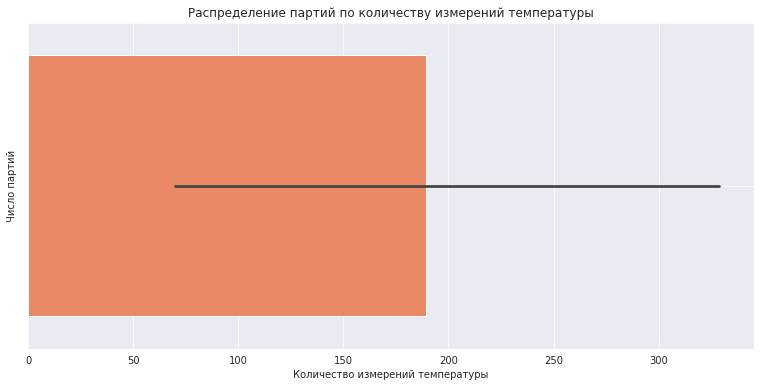

In [71]:
plt.figure(figsize=(13, 6))
sns.barplot(te_frec, color='coral')
plt.xlabel('Количество измерений температуры')
plt.ylabel('Число партий')
plt.title('Распределение партий по количеству измерений температуры')
plt.grid(True)
plt.show()

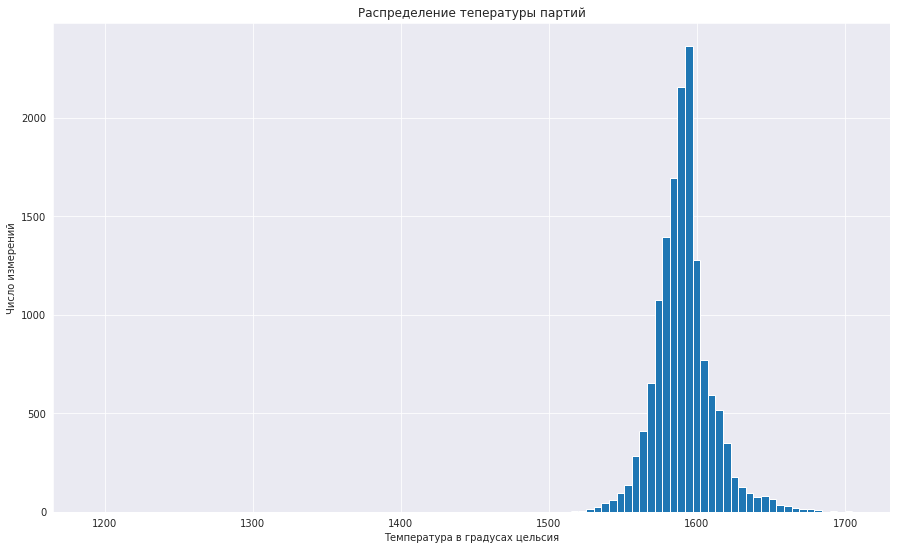

In [72]:
temp['Температура'].hist(bins=100, figsize=(15, 9))
plt.xlabel('Температура в градусах Цельсия')
plt.ylabel('Число измерений')
plt.title('Распределение температуры партий')
plt.grid(True)
plt.show()

In [73]:
temp[temp['Температура'] < 1400]

,key,Время замера,Температура
4883,867,2019-06-06 08:03:39,1191.0
6784,1214,2019-06-18 08:01:03,1208.0
9050,1619,2019-07-03 02:34:41,1218.0
11495,2052,2019-07-25 08:49:15,1227.0
14283,2561,2019-08-12 18:49:29,1204.0


In [74]:
#удалим выбросы 
nothot = temp[temp['Температура'] < 1400]['key'].unique()
temp = temp[~temp['key'].isin(nothot)]

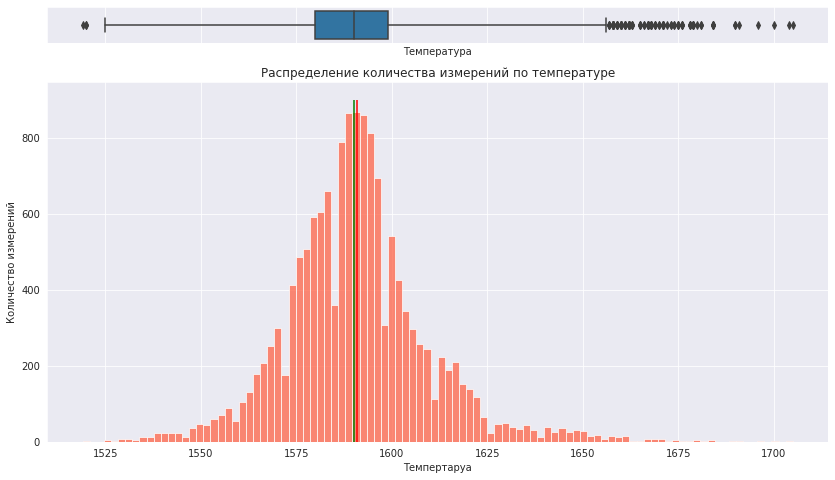

In [75]:
_, [axs_b, axs_hi] = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw=dict(height_ratios=[1, 10])) 
sns.boxplot(data=temp, x='Температура', whis=3, orient='h', ax=axs_b)
sns.histplot(data=temp, x='Температура', bins=100, color='tomato', ax=axs_hi)
plt.vlines(temp['Температура'].mean(), ymin=0, ymax=900, colors='red', label='среднее')
plt.vlines(temp['Температура'].median(), ymin=0, ymax=900, colors='green', label='медиана')
plt.xlabel('Температура')
plt.ylabel('Количество измерений')
plt.title('Распределение количества измерений по температуре')
plt.grid(True)
plt.show()

In [76]:
temp[temp['Температура'].isna()]

,key,Время замера,Температура
13927,2500,2019-08-10 14:13:11,NaN
13928,2500,2019-08-10 14:18:12,NaN
13929,2500,2019-08-10 14:25:53,NaN
13930,2500,2019-08-10 14:29:39,NaN
13932,2501,2019-08-10 14:49:15,NaN
...,...,...,...
18087,3241,2019-09-06 16:55:01,NaN
18088,3241,2019-09-06 17:06:38,NaN
18089,3241,2019-09-06 17:21:48,NaN
18090,3241,2019-09-06 17:24:44,NaN


In [77]:
temp[temp['Температура'].isna()]['key'].unique()

array([2500, 2501, 2502, 2503, 2504, 2505, 2506, 2507, 2508, 2509, 2510,
       2511, 2512, 2513, 2514, 2515, 2516, 2517, 2518, 2519, 2520, 2521,
       2522, 2523, 2524, 2525, 2526, 2527, 2528, 2529, 2530, 2531, 2532,
       2533, 2534, 2535, 2536, 2537, 2538, 2539, 2540, 2541, 2542, 2543,
       2544, 2545, 2546, 2547, 2548, 2549, 2550, 2551, 2552, 2553, 2554,
       2555, 2556, 2557, 2558, 2559, 2560, 2562, 2563, 2564, 2565, 2566,
       2567, 2568, 2569, 2570, 2571, 2572, 2573, 2574, 2575, 2576, 2577,
       2578, 2579, 2580, 2581, 2582, 2583, 2584, 2585, 2586, 2587, 2588,
       2589, 2590, 2591, 2592, 2593, 2594, 2595, 2596, 2597, 2598, 2599,
       2600, 2601, 2602, 2603, 2604, 2605, 2606, 2607, 2608, 2609, 2610,
       2611, 2612, 2613, 2614, 2615, 2616, 2617, 2618, 2619, 2620, 2621,
       2622, 2623, 2624, 2625, 2626, 2627, 2628, 2629, 2630, 2631, 2632,
       2633, 2634, 2635, 2636, 2637, 2638, 2639, 2640, 2641, 2642, 2643,
       2644, 2645, 2646, 2647, 2648, 2649, 2650, 26

In [78]:
temp[temp['Температура'].isna()]['key'].nunique()

738

In [79]:
temp[temp['key'] == 3000]

,key,Время замера,Температура
16804,3000,2019-08-29 09:48:33,1609.0
16805,3000,2019-08-29 09:53:47,NaN
16806,3000,2019-08-29 10:00:59,NaN
16807,3000,2019-08-29 10:06:16,NaN


Пропуски есть и в значении целевой переменной, заполним пропуски 0, чтобы понять, в скольких партиях есть пропуск в целевой переменной

In [80]:
temp = temp.fillna(0)

Пропуски присутствуют в более чем 700 партиях, сначала выделим, какие были начальные и итоговые замеры, а потом посмотрим, есть ли среди них пропуски для удаления этих партий, на случай если можно оставить партии, где Nan только среди промежуточных значений

In [81]:
temp_so = temp.sort_values(['key', 'Время замера'])
te = temp_so.groupby('key').agg({'Температура': ['first', 'last'],'Время замера': ['first', 'last']}).reset_index()
te.columns = ['key', 'start_temp', 'end_temp', 'start_time', 'end_time']
te.head()

,key,start_temp,end_temp,start_time,end_time
0,1,1571.0,1613.0,2019-05-03 11:02:04,2019-05-03 11:30:38
1,2,1581.0,1602.0,2019-05-03 11:34:04,2019-05-03 11:55:09
2,3,1596.0,1599.0,2019-05-03 12:06:44,2019-05-03 12:35:57
3,4,1601.0,1625.0,2019-05-03 12:39:27,2019-05-03 12:59:47
4,5,1576.0,1602.0,2019-05-03 13:11:03,2019-05-03 13:36:39


In [82]:
te.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3211 entries, 0 to 3210
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   key         3211 non-null   int64         
 1   start_temp  3211 non-null   float64       
 2   end_temp    3211 non-null   float64       
 3   start_time  3211 non-null   datetime64[ns]
 4   end_time    3211 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 125.6 KB


In [83]:
te.describe()

,key,start_temp,end_temp
count,3211.000000,3211.000000,3211.000000
mean,1622.136406,1589.182186,1228.673622
std,935.516343,25.019995,671.453034
min,1.000000,1519.000000,0.000000
25%,814.500000,1572.000000,1574.000000
50%,1623.000000,1588.000000,1590.000000
75%,2431.500000,1606.000000,1597.000000
max,3241.000000,1684.000000,1700.000000


In [84]:
te[te['end_temp'] == 0].shape

(738, 5)

Придётся удалить все партии без целевого значения.

In [85]:
notarget= te[te['end_temp'] == 0]['key'].unique()
te = te[~te['key'].isin(notarget)]

In [86]:
te.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2473 entries, 0 to 2472
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   key         2473 non-null   int64         
 1   start_temp  2473 non-null   float64       
 2   end_temp    2473 non-null   float64       
 3   start_time  2473 non-null   datetime64[ns]
 4   end_time    2473 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 115.9 KB


Таким образом, были удалены партии с пропусками в целевой переменной и выбросы, не соответствующие реальным измерениям

In [87]:
te.describe()

,key,start_temp,end_temp
count,2473.000000,2473.000000,2473.000000
mean,1249.664375,1589.016175,1595.338051
std,720.395663,24.996127,16.031388
min,1.000000,1519.000000,1541.000000
25%,627.000000,1572.000000,1587.000000
50%,1251.000000,1588.000000,1593.000000
75%,1872.000000,1605.000000,1599.000000
max,2499.000000,1679.000000,1700.000000


In [88]:
te['start_temp'] = te['start_temp'].round().astype('int')
te['end_temp'] = te['end_temp'].round().astype('int')

In [89]:
te.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2473 entries, 0 to 2472
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   key         2473 non-null   int64         
 1   start_temp  2473 non-null   int64         
 2   end_temp    2473 non-null   int64         
 3   start_time  2473 non-null   datetime64[ns]
 4   end_time    2473 non-null   datetime64[ns]
dtypes: datetime64[ns](2), int64(3)
memory usage: 115.9 KB


**Вывод**
- в датасете есть пропуски, нет дубликатов
- в датасете значительно больше строк, чем число партий, а значит замеры температуры проводились несколько раз - нас интересует последний замер
- есть значения меньше 1400 градусов - минимально необходимой температуры для плавления стали (информация получена от заказчика), данные значения были удалены
- изначально уникальных значений партий 3216 из 3241, значит температура указана не для всех партий, после удаления аномальных значений в температуре - уникальных значений партий стало 3211
- количество измерений температуры и нагревания электродами совпадают
- пропуски обнаружены в измерениях с партиями от 2500 до 3241 и были удалены, так как пропуски были и в значениях целевой переменной - итоговое количество строк 2473
- был изменен тип данных с float на int для оптимизации хранения данных 

### Общий вывод
- нет дубликатов, но были пропуски, которые либо не были включены в итоговые датасеты, либо были заполнены нулями
- максимальное число партий - 3241, в каждом из датафреймов разное количество партий (именно они являются объектами данного исследования), что необходимо будет учесть при объединении данных в один датафрейм, мы будем использовать данные из следующих датафреймов:
    - `te` - наиболее важный, так как содержит в себе целевую переменную 
    - `arc` - был удален один из выбросов по реактивной мощности, необходимо объединить данные по партиям
    - `gas` 
    - `bu` 
    - `wi`
- были удалены аномальные значения и пропуски
- скорее всего был сбой в работе системы, или сбой в работе фабрики, или были утеряны данные за период с 14-17 июля
- распределения признаков различаются: некоторые близки к нормальному, другие имеют выраженное смещение

## EDA и объединение данных 

In [90]:
arc.head()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность,duration,minutes,power,coef,work
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,0 days 00:03:48,3.800000,0.371123,0.822181,1.159494
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,0 days 00:03:05,3.083333,0.902319,0.848545,2.360779
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,0 days 00:02:52,2.866667,0.722536,0.803161,1.663564
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,0 days 00:06:05,6.083333,0.642824,0.806591,3.154184
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,0 days 00:02:28,2.466667,1.079934,0.802950,2.138928


Из датасета с электродами мы будем объединять данные по партиям (key), нам понадобятся следующие признаки:
- количество минут - суммируем данный показатель
- работа - суммируем, так как энергия аддитивная величина - покажет сколько энергии ушло на нагрев
- полная мощность - средневзвешенная по времени, так как влияние мощности зависит от времени, при таком вычислении будем учитывать вклад каждой мощности
- коэффициент мощности - средневзвешенная по работе, аналогично примеру выше - покажет качество используемой энергии, насколько эффективно электричество преобразуется в тепло


In [91]:
arc_gr = arc.groupby('key')
arc_new = []
for key, gr in arc_gr:
    n_iter = len(gr)
    minutes = gr['minutes'].sum()
    tot_work = gr['work'].sum()
    avg_power = np.average(gr['power'], weights=gr['minutes'])
    avg_coef = np.average(gr['coef'], weights=gr['work'])

    arc_new.append({
        'key': key,
        'n_iter': n_iter,
        'minutes': minutes,
        'tot_work': tot_work,
        'avg_power': avg_power,
        'avg_coef': avg_coef
    })
arc_f = pd.DataFrame(arc_new)

In [92]:
arc_f.head()

,key,n_iter,minutes,tot_work,avg_power,avg_coef
0,1,5,18.300000,10.476949,0.701532,0.816482
1,2,4,13.516667,6.588030,0.594032,0.821149
2,3,5,10.916667,9.696244,1.103569,0.805553
3,4,4,12.350000,9.061838,0.922342,0.795673
4,5,4,14.483333,6.869675,0.589379,0.805758


Возможно, в будущем мы удалим один из признаков - avg_power, minutes и n_iter, так как они могут коррелировать друг с другом

In [93]:
 arc_f.describe()

,key,n_iter,minutes,tot_work,avg_power,avg_coef
count,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000
mean,1622.907874,4.628696,13.244859,8.798805,0.822888,0.806065
std,934.844882,1.608860,5.540652,4.145861,0.174320,0.015392
min,1.000000,1.000000,0.950000,0.436459,0.331897,0.738244
25%,817.000000,4.000000,9.516667,5.980430,0.692714,0.796510
50%,1623.000000,4.000000,12.833333,8.314958,0.808328,0.807148
75%,2432.000000,6.000000,16.383333,11.153026,0.932785,0.816653
max,3241.000000,16.000000,69.816667,61.967573,1.567715,0.857042


Посмотрим на распределение данных

In [94]:
def make_visual(data, x, bins, color, ymax, xlab, ylab, title):
    _, [axs_b, axs_hi] = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw=dict(height_ratios=[1, 10])) 
    sns.boxplot(data=data, x=x, whis=3, orient='h', ax=axs_b)
    sns.histplot(data=data, x=x, bins=bins, color=color, ax=axs_hi)
    plt.vlines(data[x].mean(), ymin=0, ymax=ymax, colors='red', label='среднее')
    plt.vlines(data[x].median(), ymin=0, ymax=ymax, colors='green', label='медиана')
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title(title)
    plt.grid(True)
    plt.show()

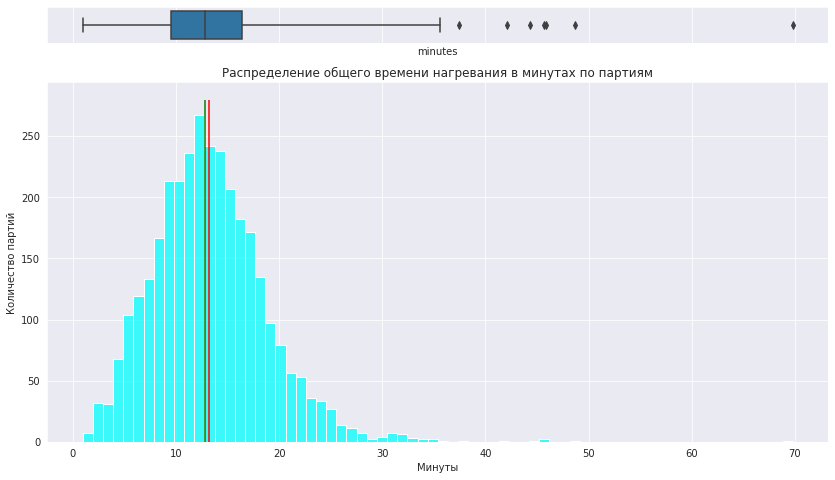

In [95]:
make_visual(arc_f, 'minutes', 70, 'cyan', 280, 'Минуты', 'Количество партий', 'Распределение общего времени нагревания в минутах по партиям')

- Большинство партий имеют оптимальное время нагрева, но есть партии, которые требуют больше времени - от 30 до 70 минут
- Такие показатели могут зависеть от химического состава или от возможных сбоев оборудования

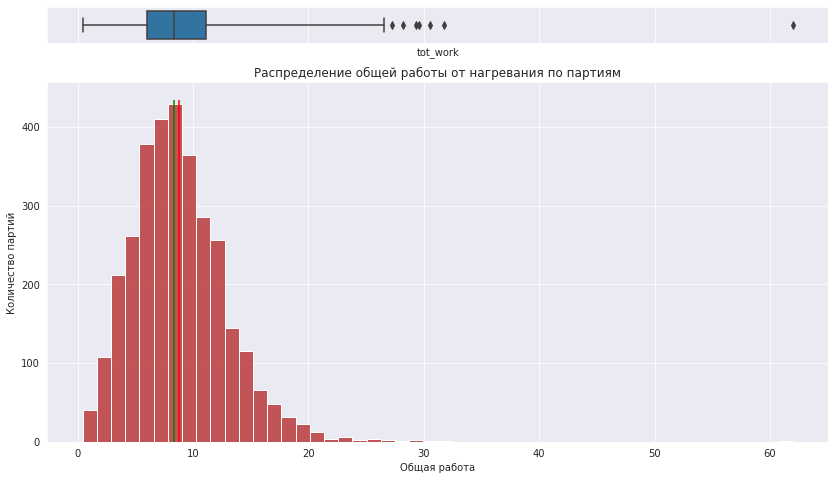

In [96]:
make_visual(arc_f, 'tot_work', 50, 'firebrick', 435, 'Общая работа', 'Количество партий', 'Распределение общей работы от нагревания по партиям')

- Энергозатраты в основном стабильны, но есть партии, потребляющие большое количество энергии, вероятна корреляция с временем
- Причины: нагрев с более низких температур, неэффективные режимы нагрева, бóльшие теплопотери в определенных партиях

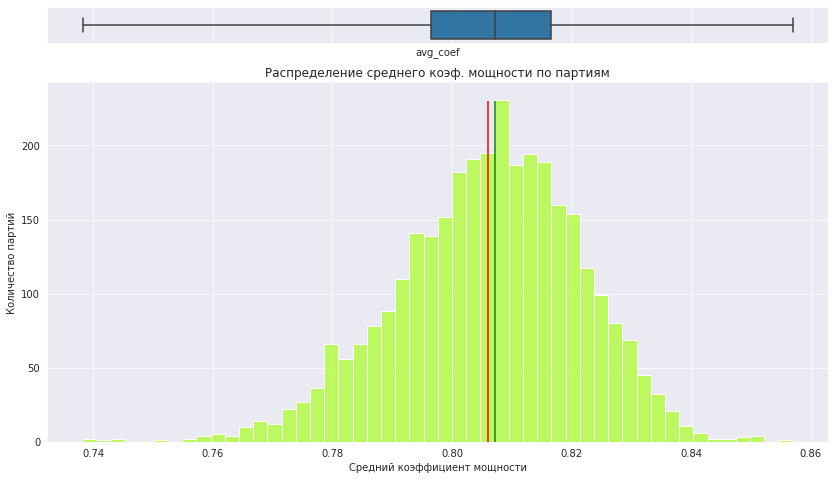

In [97]:
make_visual(arc_f, 'avg_coef', 50, 'greenyellow', 230, 'Средний коэффициент мощности', 'Количество партий', 'Распределение среднего коэффициента мощности по партиям')

- В основном хорошее качество энергии, но некоторые партии нагреваются с меньшей эффективностью
- Возможные причины: проблемы со стабильностью дуги, износ электродов

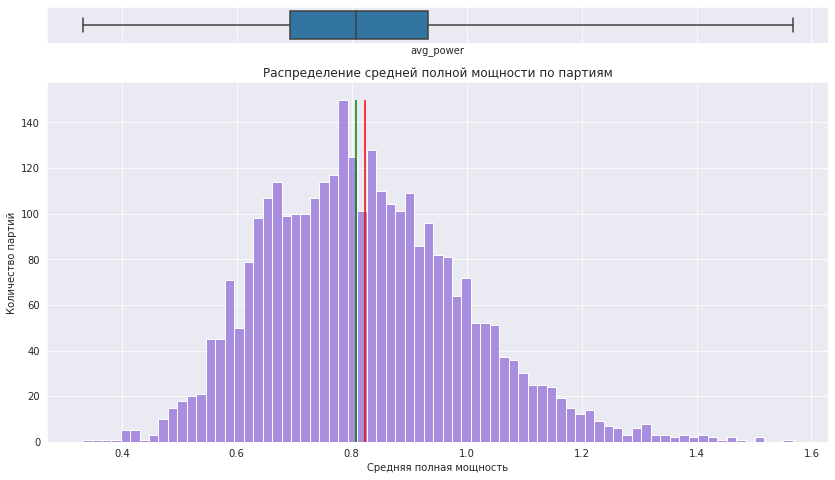

In [98]:
make_visual(arc_f, 'avg_power', 75, 'mediumpurple', 150, 'Средняя полная мощность', 'Количество партий', 'Распределение средней полной мощности по партиям')

- Есть более высокомощные нагревы (небольшое смещение влево)
- Возможная причина: в зависимости от вида сплава требовалось больше мощности

In [99]:
te.head()

,key,start_temp,end_temp,start_time,end_time
0,1,1571,1613,2019-05-03 11:02:04,2019-05-03 11:30:38
1,2,1581,1602,2019-05-03 11:34:04,2019-05-03 11:55:09
2,3,1596,1599,2019-05-03 12:06:44,2019-05-03 12:35:57
3,4,1601,1625,2019-05-03 12:39:27,2019-05-03 12:59:47
4,5,1576,1602,2019-05-03 13:11:03,2019-05-03 13:36:39


In [100]:
te['end_start_time'] = (te['end_time'] - te['start_time']).dt.total_seconds() / 60
te.head()

,key,start_temp,end_temp,start_time,end_time,end_start_time
0,1,1571,1613,2019-05-03 11:02:04,2019-05-03 11:30:38,28.566667
1,2,1581,1602,2019-05-03 11:34:04,2019-05-03 11:55:09,21.083333
2,3,1596,1599,2019-05-03 12:06:44,2019-05-03 12:35:57,29.216667
3,4,1601,1625,2019-05-03 12:39:27,2019-05-03 12:59:47,20.333333
4,5,1576,1602,2019-05-03 13:11:03,2019-05-03 13:36:39,25.600000


In [101]:
te_f = te.drop(['start_time', 'end_time'], axis=1)
te_f.head()

,key,start_temp,end_temp,end_start_time
0,1,1571,1613,28.566667
1,2,1581,1602,21.083333
2,3,1596,1599,29.216667
3,4,1601,1625,20.333333
4,5,1576,1602,25.600000


In [102]:
te_f.describe()

,key,start_temp,end_temp,end_start_time
count,2473.000000,2473.000000,2473.000000,2473.000000
mean,1249.664375,1589.016175,1595.338051,37.991212
std,720.395663,24.996127,16.031388,22.921968
min,1.000000,1519.000000,1541.000000,0.000000
25%,627.000000,1572.000000,1587.000000,25.683333
50%,1251.000000,1588.000000,1593.000000,33.450000
75%,1872.000000,1605.000000,1599.000000,45.650000
max,2499.000000,1679.000000,1700.000000,394.566667


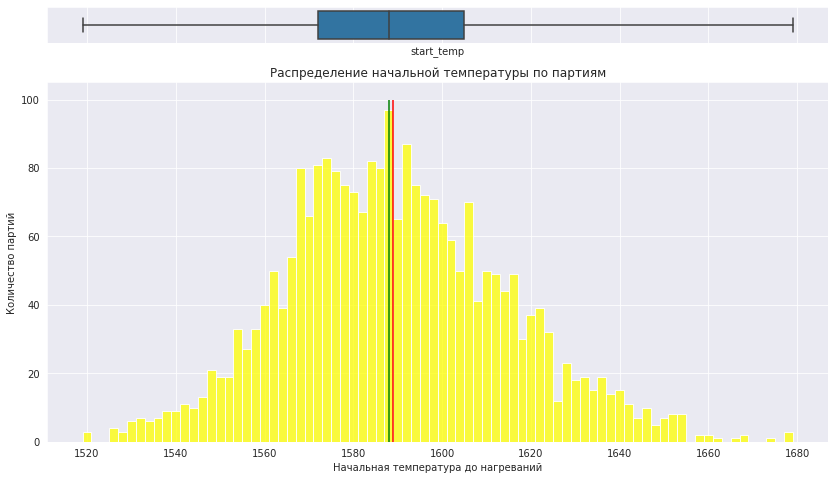

In [103]:
make_visual(te_f, 'start_temp', 80, 'yellow', 100, 'Начальная температура до нагреваний', 'Количество партий', 'Распределение начальной температуры по партиям')

In [104]:
import scipy

stat, p = scipy.stats.shapiro(te_f['start_temp'])
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.995, p-value=0.000
Отклонить гипотезу о нормальности


- Смещение свидетельствует о том, что чаще работают с немного повышенными температурами
- Диапазон 1519-1679°C соответствует типичным температурам обработки стали

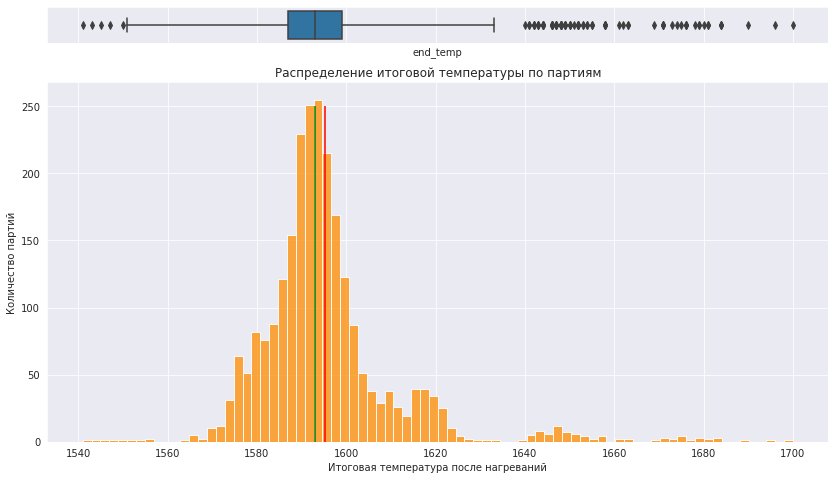

In [105]:
make_visual(te_f, 'end_temp', 80, 'darkorange', 250, 'Итоговая температура после нагреваний', 'Количество партий', 'Распределение итоговой температуры по партиям')

- Ярко выраженный пик примерно на 1590°C с более чем 250 партиями указывает на целевую температуру розлива
- Диапазон 1529-1700°C показывает возможность гибкой настройки под разные требования
- Выбросы по краям могут соответствовать:
  - Специальным маркам стали
  - Технологическим проблемам
  - Экспериментальным плавкам

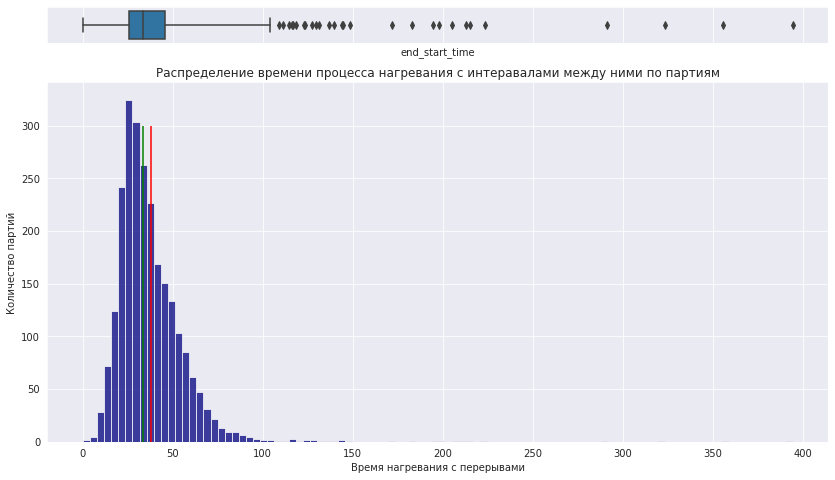

In [106]:
make_visual(te_f, 'end_start_time', 100, 'navy', 300, 'Время нагревания с перерывами', 'Количество партий', 'Распределение времени процесса нагревания с интервалами между ними по партиям')

- Пик на 25 минутах (около 300 партий) указывает на оптимальное время стандартной обработки
- Плавный спад после пика свидетельствует о вариативности процессов в зависимости от:
  - Сложности химического состава
  - Количества легирующих добавок
  - Технических проблем
- Выбросы от 100 минут могут соответствовать сложным или проблемным плавкам
- Максимум 400 минут - экстремальный случай, может указывать на сбой в системе, когда долго не было работы между нагреваниями, так как максимальное общее время нагревания - 70 минут
- Распределение похоже на общее время нагрева, но с большими значениями - подтверждает значительные периоды остывания между операциями, там медианное значение около 13 минут, то есть остывание в среднем занимает столько же или больше времени

In [107]:
gas.head()

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [108]:
gas.columns = ['key', 'gas_1']
gas.describe()

,key,gas_1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


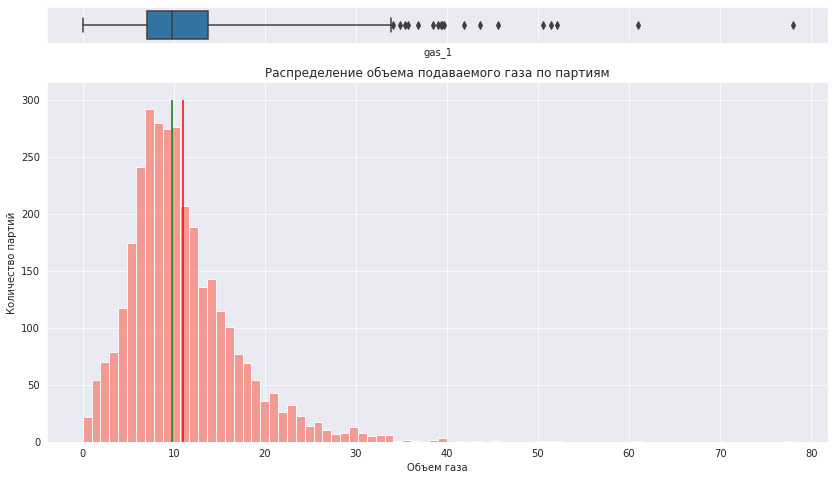

In [109]:
make_visual(gas, 'gas_1', 80, 'salmon', 300, 'Объём газа', 'Количество партий', 'Распределение объёма подаваемого газа по партиям')

- Распределение такое же как и в случае с общим числом минут, а также временем между первым и последним нагреванием
- В основном подается от 7 до 14 кубических метров (соответствует стандартным операциям продувки сплава), но есть выбросы, достигающие от 35 до 80 кубических метров, что может указывать на специальные технологические операции:
  - Интенсивная дегазация металла
  - Обработка особых марок стали
  - Удаление включений и неметаллических примесей
  - Коррекция химического состава при серьезных отклонениях 
- Есть партии, где практически не подавался газ, так как вероятно, в этом не было необходимости

In [110]:
bu.head()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0
1,2,0.0,0.0,0.0,73.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,149.0,154.0
2,3,0.0,0.0,0.0,34.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,205.0,0.0,152.0,153.0
3,4,0.0,0.0,0.0,81.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,207.0,0.0,153.0,154.0
4,5,0.0,0.0,0.0,78.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,203.0,0.0,151.0,152.0


In [111]:
bu.describe().T

,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.0,1622.0,2431.0,3241.0
Bulk 1,3129.0,3.160435,11.869164,0.0,0.0,0.0,0.0,185.0
Bulk 2,3129.0,1.779163,21.217878,0.0,0.0,0.0,0.0,325.0
Bulk 3,3129.0,47.240332,74.239954,0.0,0.0,0.0,80.0,454.0
Bulk 4,3129.0,33.830617,56.034505,0.0,0.0,0.0,68.0,281.0
Bulk 5,3129.0,2.633749,20.918138,0.0,0.0,0.0,0.0,603.0
Bulk 6,3129.0,21.892298,55.492582,0.0,0.0,0.0,0.0,503.0
Bulk 7,3129.0,2.441675,31.944063,0.0,0.0,0.0,0.0,772.0
Bulk 8,3129.0,0.015660,0.875978,0.0,0.0,0.0,0.0,49.0
Bulk 9,3129.0,0.463407,6.154398,0.0,0.0,0.0,0.0,147.0


In [112]:
wi.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,96.052315,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,91.160157,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,89.063515,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,89.238236,9.11456,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [113]:
wi.describe().T

,count,mean,std,min,25%,50%,75%,max
key,3081.0,1623.426485,932.996726,1.0,823.00000,1619.000000,2434.000000,3241.000000
Wire 1,3081.0,100.044411,42.841120,0.0,70.28112,100.114563,125.798405,330.314424
Wire 2,3081.0,17.712733,33.517734,0.0,0.00000,0.000000,23.162880,282.780152
Wire 3,3081.0,3.874524,30.310417,0.0,0.00000,0.000000,0.000000,385.008668
Wire 4,3081.0,0.261019,4.293865,0.0,0.00000,0.000000,0.000000,113.231044
Wire 5,3081.0,0.004911,0.272615,0.0,0.00000,0.000000,0.000000,15.132000
Wire 6,3081.0,1.137695,8.958111,0.0,0.00000,0.000000,0.000000,180.454575
Wire 7,3081.0,0.035842,0.774190,0.0,0.00000,0.000000,0.000000,32.847674
Wire 8,3081.0,0.330697,4.392677,0.0,0.00000,0.000000,0.000000,102.762401
Wire 9,3081.0,0.321492,3.806904,0.0,0.00000,0.000000,0.000000,90.053604


В обоих датасетах есть значения партий, которые отсутствуют, скорее всего в эти партии не добавлялись никакие из сыпучих или проволочных материалов, при объединении таблиц ячейки можно будет заполнить 0.

In [114]:
df = pd.merge(left= te_f, right= arc_f, how='inner', on='key')
df.head()

,key,start_temp,end_temp,end_start_time,n_iter,minutes,tot_work,avg_power,avg_coef
0,1,1571,1613,28.566667,5,18.300000,10.476949,0.701532,0.816482
1,2,1581,1602,21.083333,4,13.516667,6.588030,0.594032,0.821149
2,3,1596,1599,29.216667,5,10.916667,9.696244,1.103569,0.805553
3,4,1601,1625,20.333333,4,12.350000,9.061838,0.922342,0.795673
4,5,1576,1602,25.600000,4,14.483333,6.869675,0.589379,0.805758


In [115]:
df = pd.merge(left= df, right= gas, how='inner', on='key')
df = pd.merge(left= df, right= bu, how='inner', on='key')
df = pd.merge(left= df, right= wi, how='inner', on='key')
df.head()

,key,start_temp,end_temp,end_start_time,n_iter,minutes,tot_work,avg_power,avg_coef,gas_1,...,Bulk 15,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,1571,1613,28.566667,5,18.300000,10.476949,0.701532,0.816482,29.749986,...,154.0,60.059998,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,1581,1602,21.083333,4,13.516667,6.588030,0.594032,0.821149,12.555561,...,154.0,96.052315,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,1596,1599,29.216667,5,10.916667,9.696244,1.103569,0.805553,28.554793,...,153.0,91.160157,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,1601,1625,20.333333,4,12.350000,9.061838,0.922342,0.795673,18.841219,...,154.0,89.063515,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,1576,1602,25.600000,4,14.483333,6.869675,0.589379,0.805758,5.413692,...,152.0,89.238236,9.11456,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [116]:
df.isna().sum()

key               0
start_temp        0
end_temp          0
end_start_time    0
n_iter            0
minutes           0
tot_work          0
avg_power         0
avg_coef          0
gas_1             0
Bulk 1            0
Bulk 2            0
Bulk 3            0
Bulk 4            0
Bulk 5            0
Bulk 6            0
Bulk 7            0
Bulk 8            0
Bulk 9            0
Bulk 10           0
Bulk 11           0
Bulk 12           0
Bulk 13           0
Bulk 14           0
Bulk 15           0
Wire 1            0
Wire 2            0
Wire 3            0
Wire 4            0
Wire 5            0
Wire 6            0
Wire 7            0
Wire 8            0
Wire 9            0
dtype: int64

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2324 entries, 0 to 2323
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   key             2324 non-null   int64  
 1   start_temp      2324 non-null   int64  
 2   end_temp        2324 non-null   int64  
 3   end_start_time  2324 non-null   float64
 4   n_iter          2324 non-null   int64  
 5   minutes         2324 non-null   float64
 6   tot_work        2324 non-null   float64
 7   avg_power       2324 non-null   float64
 8   avg_coef        2324 non-null   float64
 9   gas_1           2324 non-null   float64
 10  Bulk 1          2324 non-null   float64
 11  Bulk 2          2324 non-null   float64
 12  Bulk 3          2324 non-null   float64
 13  Bulk 4          2324 non-null   float64
 14  Bulk 5          2324 non-null   float64
 15  Bulk 6          2324 non-null   float64
 16  Bulk 7          2324 non-null   float64
 17  Bulk 8          2324 non-null   f

In [118]:
#построим матрицу корреляций
corr = df.drop(['key'], axis=1).corr(method='spearman')

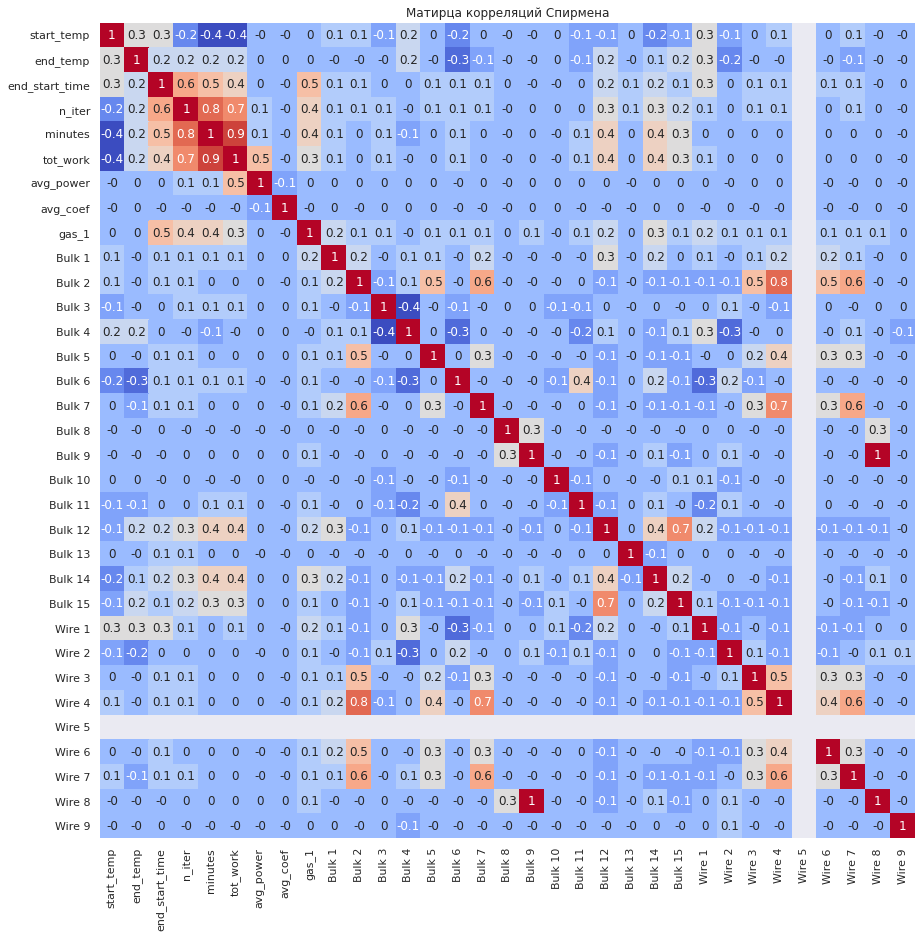

In [119]:
sns.set(rc={'figure.figsize': (15, 15)})
sns.heatmap(data=corr.round(1), cmap='coolwarm', annot=True, square=True, cbar=False).set(title='Матрица корреляций Спирмена');

- Есть прямая корреляция между признаками Bulk 9 и Wire 8 - один из признаков можем удалить
- признак Wire 5 также удалим, так как на его основе нельзя понять взаимосвязь с целевой переменной
- также есть довольно высокая корреляция между общим числом минут и общей работой, возможно, удалим признак минут
- у целевого признака пока заметна только корреляция с признаком начальной температуры, вероятно, линейная регрессия не будет эффективной моделью

In [120]:
df = df.drop(['Bulk 9', 'Wire 5', 'key'], axis=1)

In [121]:
exclude = ['n_iter']
inter = df.columns.difference(exclude).tolist()

phik_ma = df.phik_matrix(interval_cols= inter)

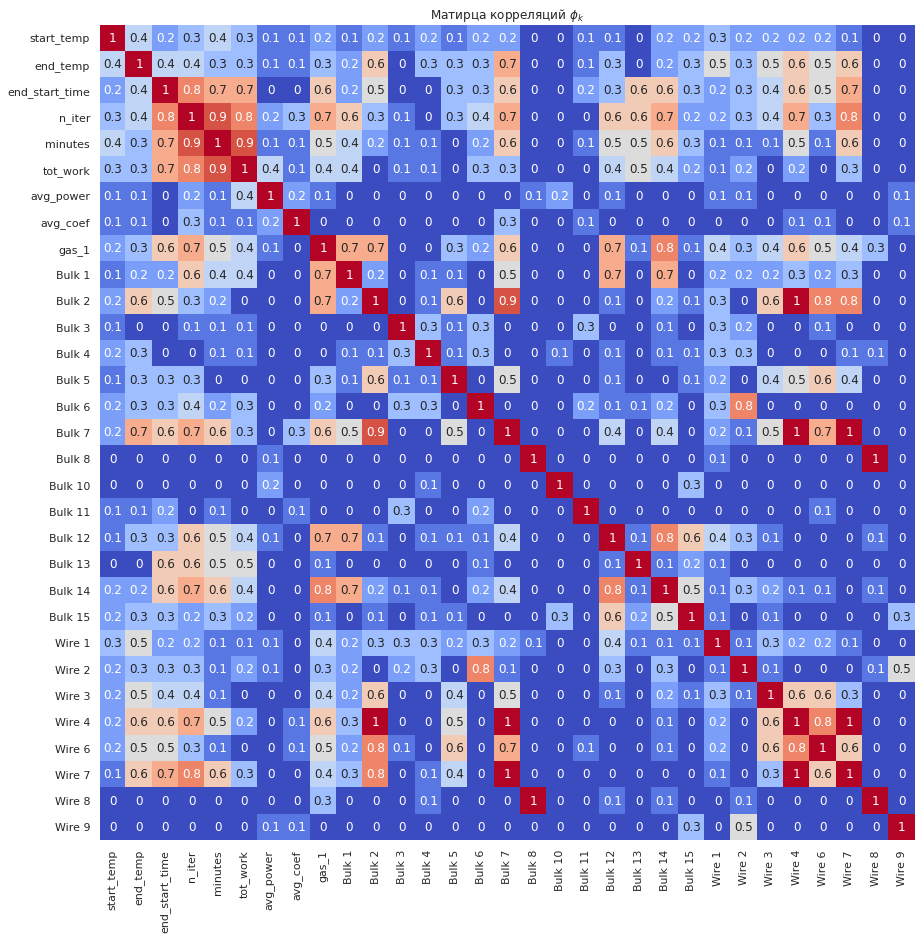

In [122]:
sns.heatmap(data=phik_ma.round(1), cmap='coolwarm', annot=True, square=True, cbar=False).set(title='Матрица корреляций $\phi_k$');

- есть сильная корреляция между признаками - `Wire 4`, `Wire 7`, `Bulk 8` - удалим эти признаки из-за мультиколлинеарности
- у целевого признака есть корреляция с Wire 1, 3, 4, 6, 7, Bulk 2 и 7

In [123]:
df = df.drop(['Wire 4', 'Wire 7', 'Bulk 8'], axis=1)

## Подготовка данных и обучение моделей

In [124]:
X = df.drop(['end_temp'], axis=1)
y = df['end_temp']

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state= RANDOM_STATE)

In [126]:
sampler = RandomSampler(seed=RANDOM_STATE)

Было выбрано несколько моделей для достижения необходимого результата с метрикой MAE <= 6.8:
- **Линейная регрессия с регуляризацией Ridge**
    - быстрый вариант для проверки линейных зависимостей
    - Ridge не удаляет признаки с малым вкладом, а делает их минимальными, данная модель позволит лучше интерпретировать весь набор признаков и их влияние на целевую переменную 
    - более устойчив к коррелирующим признакам, что поможет с учетом данных, так как корреляция между признаками более ярко выражена, чем между таргетом и признаками
- **Random Forest**
    - находит более сложные нелинейные зависимости
    - устойчивая модель к выбросам, мультиколлинеарности, разным масштабам
    - модель интерпретируема
- **CatBoost**
    - устойчив к шуму
    - модель интерпретируема
    - работа с временными зависимостями
    - поиск сложных нелинейных связей

### Ridge

In [127]:
def ridge(trial):
    
    params = {
        'alpha': trial.suggest_float('alpha', 0.1, 100.0, log=True),
        'fit_intercept': trial.suggest_categorical('fit_intercept', [True, False]),
        'solver': trial.suggest_categorical('solver', ['auto', 'cholesky', 'svd'])
    }
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(**params, random_state=RANDOM_STATE))
    ])

    scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_absolute_error', n_jobs=-1)
    
    return -scores.mean()

var = optuna.create_study(direction='minimize', sampler=sampler)
var.optimize(ridge, n_trials=50, show_progress_bar=True)

print(f"MAE: {var.best_value:.4f}")
print(f"Params: {var.best_params}")

[I 2025-11-21 05:25:15,364] A new study created in memory with name: no-name-bbbf4e41-e587-4bf3-895d-3f26757eaa61


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-21 05:25:15,811] Trial 0 finished with value: 1593.3973220337732 and parameters: {'alpha': 0.3564993230560361, 'fit_intercept': False, 'solver': 'auto'}. Best is trial 0 with value: 1593.3973220337732.
[I 2025-11-21 05:25:16,413] Trial 1 finished with value: 5.956117949738891 and parameters: {'alpha': 9.315363201348081, 'fit_intercept': True, 'solver': 'cholesky'}. Best is trial 1 with value: 5.956117949738891.
[I 2025-11-21 05:25:17,208] Trial 2 finished with value: 5.961266807309414 and parameters: {'alpha': 0.7686828237937703, 'fit_intercept': True, 'solver': 'svd'}. Best is trial 1 with value: 5.956117949738891.
[I 2025-11-21 05:25:17,910] Trial 3 finished with value: 1593.3978104586395 and parameters: {'alpha': 58.38106458667106, 'fit_intercept': False, 'solver': 'svd'}. Best is trial 1 with value: 5.956117949738891.
[I 2025-11-21 05:25:18,409] Trial 4 finished with value: 1593.3973861655995 and parameters: {'alpha': 1.2435454011060976, 'fit_intercept': False, 'solver':

### Random Forest

In [128]:
def rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 8, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4)
    }
    
    model = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    
    return -scores.mean()

# Оптимизация Random Forest
var_2 = optuna.create_study(direction='minimize', sampler=sampler)
var_2.optimize(rf, n_trials=50, show_progress_bar=True)

print(f"MAE: {var_2.best_value:.4f}")
print(f"Params: {var_2.best_params}")

[I 2025-11-21 05:28:45,240] A new study created in memory with name: no-name-a57b4bff-0357-4e87-843b-b4e8e1be9606


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-21 05:28:48,419] Trial 0 finished with value: 6.15326025376563 and parameters: {'n_estimators': 54, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 0 with value: 6.15326025376563.
[I 2025-11-21 05:28:56,363] Trial 1 finished with value: 6.092123119028527 and parameters: {'n_estimators': 127, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 1}. Best is trial 1 with value: 6.092123119028527.
[I 2025-11-21 05:29:08,110] Trial 2 finished with value: 6.080472991963054 and parameters: {'n_estimators': 194, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 2 with value: 6.080472991963054.
[I 2025-11-21 05:29:14,678] Trial 3 finished with value: 6.1020932680458175 and parameters: {'n_estimators': 138, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 2 with value: 6.080472991963054.
[I 2025-11-21 05:29:20,339] Trial 4 finished with value: 6.110305771723935 and parameters: {'n_estimat

### CatBoost

In [129]:
def catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'verbose': False
    }
    
    model = CatBoostRegressor(**params, random_state=RANDOM_STATE)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=kf, 
                           scoring='neg_mean_absolute_error', n_jobs=1)  # CatBoost не поддерживает n_jobs=-1 в CV
    
    return -scores.mean()

var_3 = optuna.create_study(direction='minimize', sampler=sampler)
var_3.optimize(catboost, n_trials=50, show_progress_bar=True)
print(f"MAE: {var_3.best_value:.4f}")
print(f"Params: {var_3.best_params}")

[I 2025-11-21 05:49:25,035] A new study created in memory with name: no-name-79759ae9-ee42-4434-8ef5-436a7fbc638c


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-21 05:49:41,384] Trial 0 finished with value: 6.123049619687895 and parameters: {'iterations': 401, 'depth': 7, 'learning_rate': 0.2643028346400706}. Best is trial 0 with value: 6.123049619687895.
[I 2025-11-21 05:49:48,447] Trial 1 finished with value: 5.8874626998814445 and parameters: {'iterations': 367, 'depth': 4, 'learning_rate': 0.056892023411877116}. Best is trial 1 with value: 5.8874626998814445.
[I 2025-11-21 05:50:00,723] Trial 2 finished with value: 6.229521965110577 and parameters: {'iterations': 276, 'depth': 7, 'learning_rate': 0.019349578180060587}. Best is trial 1 with value: 5.8874626998814445.
[I 2025-11-21 05:50:05,858] Trial 3 finished with value: 6.296770118756705 and parameters: {'iterations': 148, 'depth': 4, 'learning_rate': 0.03916426556899054}. Best is trial 1 with value: 5.8874626998814445.
[I 2025-11-21 05:50:40,081] Trial 4 finished with value: 6.03583554613792 and parameters: {'iterations': 249, 'depth': 9, 'learning_rate': 0.06409975886594077}

In [130]:
ri = round(var.best_value, 3)
rfo = round(var_2.best_value, 3)
cat = round(var_3.best_value, 3)

In [131]:
res = pd.DataFrame({'Ridge': [ri], 'RandomForest': [rfo], 'CatBoost': [cat]})
res = res.rename_axis(index='MAE')
res

,Ridge,RandomForest,CatBoost
MAE,,,
0,5.956,6.08,5.887


**Вывод**
- были выбраны 3 модели:
    - линейная регрессия с регуляризацией
    - Случайный лес
    - CatBoost
- модели были обучены на кросс-валидации
- среди них наилучший результат показала CatBoost

## Тестирование модели

In [132]:
params = var_3.best_params
model = CatBoostRegressor(**params, random_state=RANDOM_STATE, verbose=False)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print(f'MAE = {round(mae, 2)}')

MAE = 5.98


На тестовых данных значение MAE стало немного выше, но результат продолжает быть очень хорошим. MAE более чем соответствует требованию заказчика

## Анализ важности признаков

In [133]:
feature_names = X_train.columns
importance = model.get_feature_importance()
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
    }).sort_values('importance', ascending=False)
imp_df

,feature,importance
0,start_temp,25.253365
3,minutes,21.552999
1,end_start_time,9.087929
4,tot_work,5.903811
13,Bulk 6,5.629830
22,Wire 2,4.419954
20,Bulk 15,4.196636
21,Wire 1,3.863569
17,Bulk 12,2.944646
19,Bulk 14,2.793314


In [134]:
exp = shap.TreeExplainer(model)
sh = exp.shap_values(X_test)

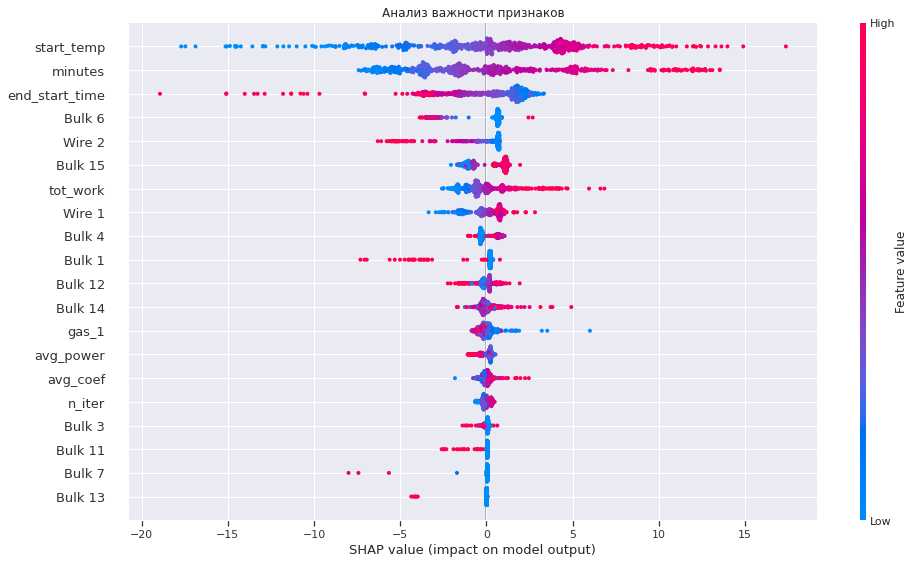

In [135]:
shap.summary_plot(sh, X_test, feature_names=feature_names, 
                     show=False, plot_size=(14, 8))
plt.title('Анализ важности признаков')
plt.tight_layout()
plt.show()

In [ ]:
shap_val = exp(X_test)
shap.plots.bar(shap_val, show=False)
plt.title('SHAP - Важность признаков')
plt.tight_layout()
plt.show()

**Вывод**
- наиболее важными признаками оказалась начальная температура и время нагревания - именно от них больше всего зависит итоговая температура, третьим по важности признаком оказалось общее время процесса обработки стали от первого до итогового нагревания, но он может быть настолько значимым из-за содержания в нем признака времени нагревания
- также влияние оказывают разные виды добавляемых материалов - `Bulk 6`, `Bulk 15`, `Wire 2`
- Общая работа на удивление оказалась менее весомым признаком - она также оказывает влияние, но не такое сильное, как факторы времени и температуры

Итоговая температура сильнее всего определяется начальными условиями и временными характеристиками, а не суммарной мощностью

## Итоговый вывод

1. Возникшие трудности и способы их преодоления
- **Неполные и неоднородные данные**
    - Данные поступали из нескольких файлов и не совпадали по числу партий
    - Пропуски в добавках Bulk/Wire означали отсутствие добавки → заменены нулями
    - Пропуски в температуре как целевой переменной → удалены, так как невозможно восстановить
    - В описании данных не были указаны единицы измерения мощности
    - Был период, за который отсутствовали данные
- **Аномальные наблюдения:** Выбросы в температуре и реактивной мощности → удалены, так как не соответствуют реальности 
- **Мультиколлинеарность:** Удалены признаки с корреляцией = 1 (Bulk 9, Wire 8, Wire 4, Wire 7, Bulk 8)
- Выбор партии как объекта моделирования
- Были добавлены **новые признаки**: временные на основе дат, физические (работа, коэффициент мощности, полная мощность)

2. Модель:

**Итоговые признаки модели**
- **start_temp** — стартовая температура (оказывает наибольшее влияние)  
- **minutes** — время чистого нагрева электродами  
- **end_start_time** — полный цикл обработки (нагрев + корректировка + охлаждение)  
- **avg_power**, **avg_coef**, **tot_work** — физические параметры энергопотребления  
- **Bulk n / Wire n** — объёмы добавленных в ковш материалов  
- **gas_1** — объём газовой обработки  

**Лучшая модель** - CatBoostRegressor
Лучшие параметры:

```python
best_params = {
    'iterations': 322,
    'depth': 4,
    'learning_rate': 0.0654497721829455,
    'random_state': 42
}
```

**Метрика на тесте**: MAE = 5.98 - соответствует требованию заказчика

**Анализ SHAP**: основные факторы — начальная температура, время нагрева и общая длительность процесса

3. Рекомендации

По улучшению модели:
- Добавить физические признаки процесса (масса стали в ковше, химический состав, температура окружающей среды, износ ковша)
- Добавить дополнительные физические признаки (расход энергии на 1 °C, коэффициент эффективности нагрева), учитывать изменение температуры на промежуточных этапах
- Исследовать на человеческий фактор

**Снижение энергопотребления**
- Создать модель раннего выявления «неэффективных плавок»
    - Определить нормальный диапазон температур
    - Помечать партии, которые: перегреваются, долго греются, требуют много итераций
    - Собирать и анализировать параметры таких партий: материалы, энергопотребление, технологический режим, работа газом, параметры бригады

- Модель прогнозирования энергопотребления
    - Прогнозировать не только температуру, но и расход энергии
    - Выявлять «дорогие» плавки заранее
    - Рекомендовать оптимизации по времени нагрева

- Оптимизация технологического цикла
    - Найти минимально достаточное время нагрева
    - Автоматически рекомендовать момент остановки нагрева, когда прирост температуры становится неэффективным

**Применение**: Встроить модель в систему диспетчеризации и отправлять бригаде данные об ожидаемой финальной температуре, риске перегрева, текущей эффективности нагрева.